In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import LabelEncoder

## **Data Reading:**

In [2]:
df = pd.read_csv('first inten project.csv')
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


## **Data Cleaning & Preprocessing:**

In [3]:
df.shape

(36285, 17)

In [4]:
df.isnull()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36280,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
36281,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
36282,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
36283,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### **Check Null and missing values:**

In [5]:
df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [6]:
df[df.isnull()].head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

### **Using heatmap to identify the missing values**

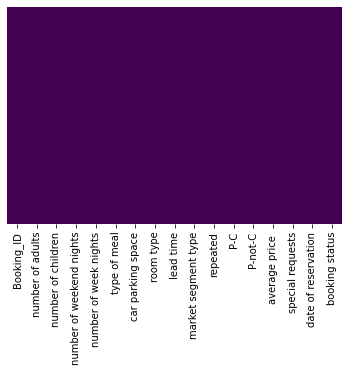

In [8]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
plt.show()

In [9]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


# **Data Visualization:**

### **What is the type of Booking status?**

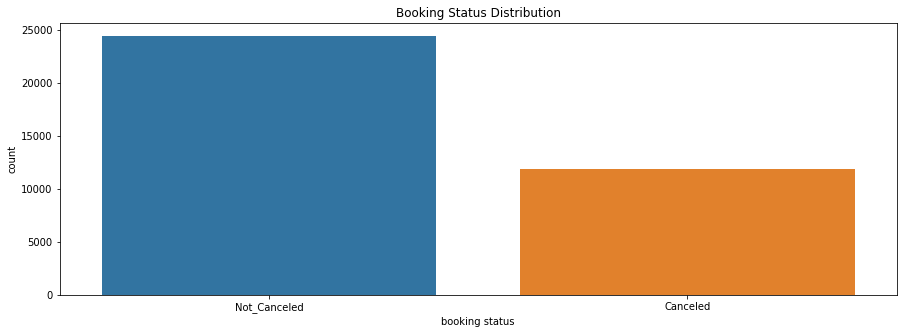

In [10]:
plt.figure(figsize=(15, 5))
sns.countplot(x = 'booking status', data = df)
plt.title('Booking Status Distribution')
plt.show()

### **What is the Distribution of Lead Time ?**

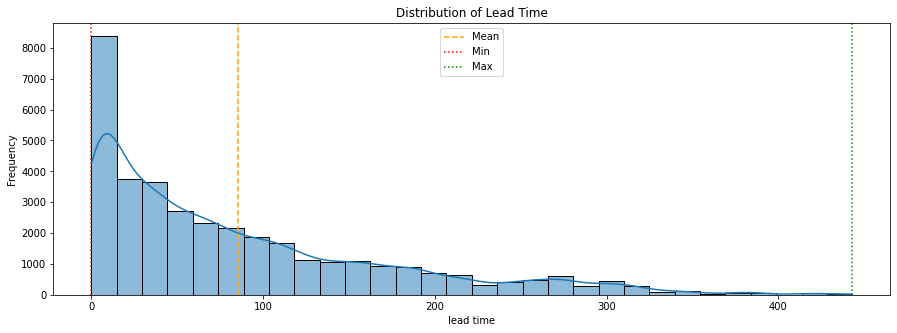

In [11]:
feature = 'lead time'
plt.figure(figsize=(15, 5))
sns.histplot(df[feature], bins = 30, kde = True)

plt.axvline(df[feature].mean(), color = 'orange', linestyle='--', label='Mean')
plt.axvline(df[feature].min(), color = 'red', linestyle=':', label='Min')
plt.axvline(df[feature].max(), color = 'green', linestyle=':', label='Max')

plt.title(f'Distribution of Lead Time')
plt.xlabel(feature)
plt.ylabel('Frequency')
plt.legend()
plt.show()


### **How does booking status distribution differ across meal types?**

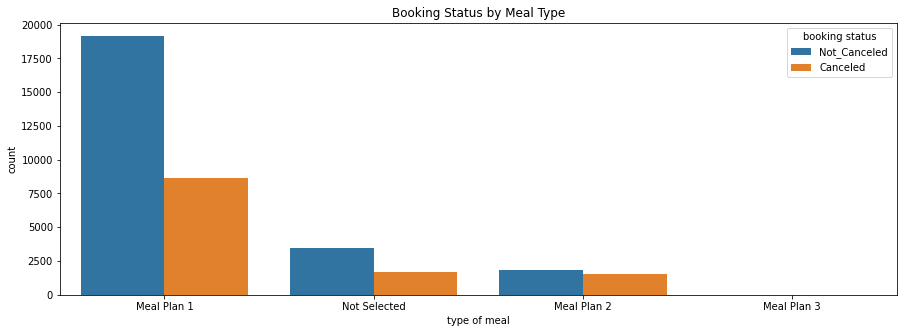

In [12]:
plt.figure(figsize=(15, 5))
sns.countplot(x = 'type of meal', hue = 'booking status', data = df)
plt.title('Booking Status by Meal Type')
plt.show()

### **What is the median lead time for canceled bookings?**

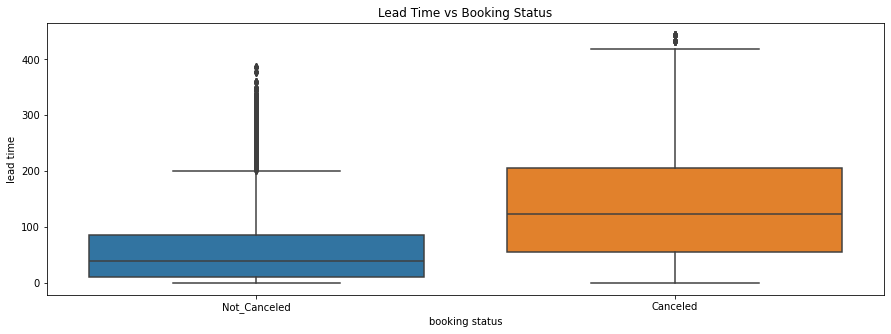

In [13]:
# Lead time vs booking status
plt.figure(figsize=(15, 5))
sns.boxplot(x = 'booking status', y = 'lead time', data = df)
plt.title('Lead Time vs Booking Status')
plt.show()

### **Do guests who make more special requests tend to cancel less?**

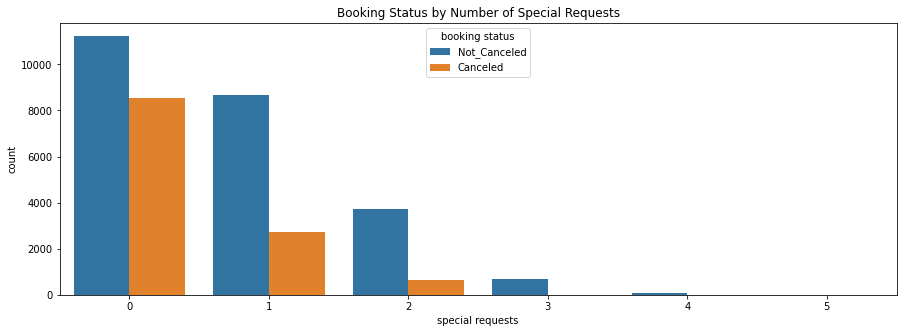

In [14]:
plt.figure(figsize=(15, 5))
sns.countplot(x = 'special requests', hue = 'booking status', data = df)
plt.title('Booking Status by Number of Special Requests')
plt.show()


### **Which market segments generate the most stable bookings?**

In [15]:
df['market segment type'].value_counts().index

Index(['Online', 'Offline', 'Corporate', 'Complementary', 'Aviation'], dtype='object')

In [16]:
# Group by market segment and booking status
segment_status = df.groupby(['market segment type', 'booking status']).size().unstack(fill_value = 0)
segment_status

booking status,Canceled,Not_Canceled
market segment type,,
Aviation,37,88
Complementary,0,391
Corporate,220,1797
Offline,3154,7377
Online,8478,14743


In [17]:
# Calculate total and cancellation rate
segment_status['total'] = segment_status.sum(axis = 1)
segment_status['cancellation_rate'] = segment_status['Canceled'] / segment_status['total']
# Sort by cancellation rate (lower = more stable)
segment_status_sorted = segment_status.sort_values('cancellation_rate')

In [18]:
segment_status_sorted

booking status,Canceled,Not_Canceled,total,cancellation_rate
market segment type,,,,
Complementary,0,391,391,0.000000
Corporate,220,1797,2017,0.109073
Aviation,37,88,125,0.296000
Offline,3154,7377,10531,0.299497
Online,8478,14743,23221,0.365101


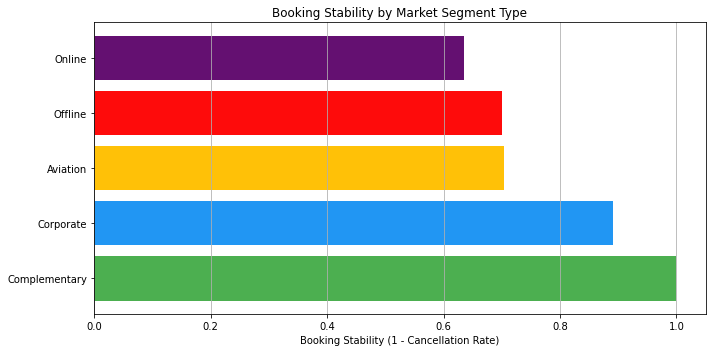

In [19]:
color_list = ['#4CAF50', '#2196F3', '#FFC107', "#FE0B0B", "#641071"]  

plt.figure(figsize=(10, 5))
plt.barh(
    segment_status_sorted.index,
    1 - segment_status_sorted['cancellation_rate'],
    color=color_list[:len(segment_status_sorted)]
)

plt.xlabel('Booking Stability (1 - Cancellation Rate)')
plt.title('Booking Stability by Market Segment Type')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


### **How does the distribution of adults and children look across hotel bookings?**

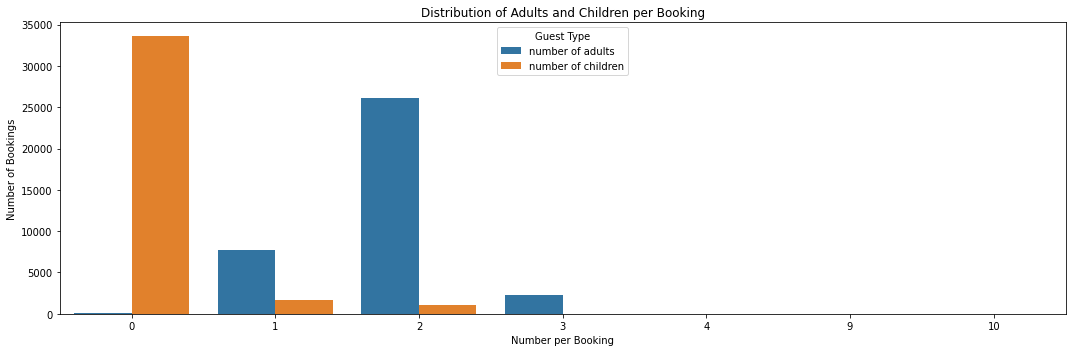

In [20]:
guest_type = df.melt(value_vars = ['number of adults', 'number of children'], 
                 var_name = 'Guest Type', 
                 value_name = 'Count')

plt.figure(figsize = (15, 5))
sns.countplot(data = guest_type, x = 'Count', hue = 'Guest Type')
plt.title('Distribution of Adults and Children per Booking')
plt.xlabel('Number per Booking')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()


In [21]:
df.drop('Booking_ID', axis = 1, inplace = True)
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [22]:
print(df['booking status'].value_counts())
print(df['booking status'].value_counts(normalize = True))  


Not_Canceled    24396
Canceled        11889
Name: booking status, dtype: int64
Not_Canceled    0.672344
Canceled        0.327656
Name: booking status, dtype: float64


## **Dealing with Outliers:**

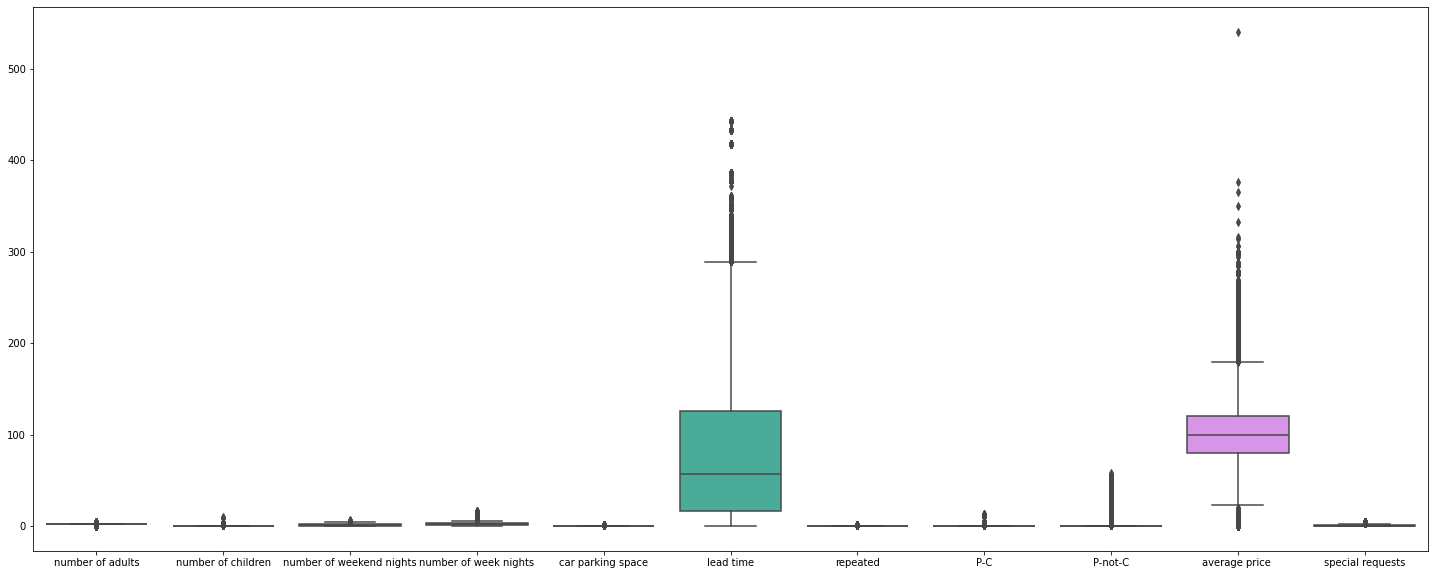

In [23]:
plt.figure(figsize = (25,10)) 
sns.boxplot(data = df)
plt.show()

In [24]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)
    return df


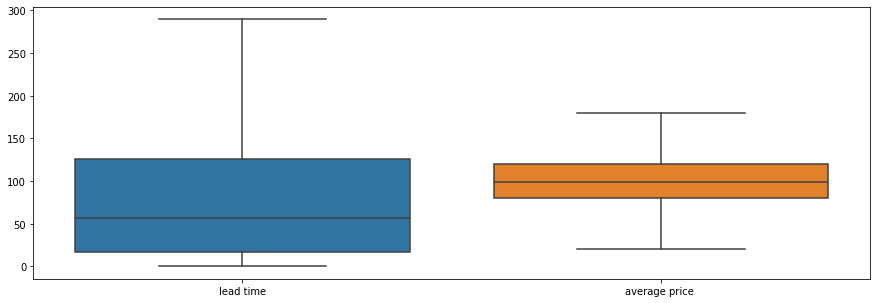

In [25]:
outlier_cols = ['lead time', 'average price ']
for col in outlier_cols:
    df = cap_outliers(df, col)
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[outlier_cols])
plt.show()


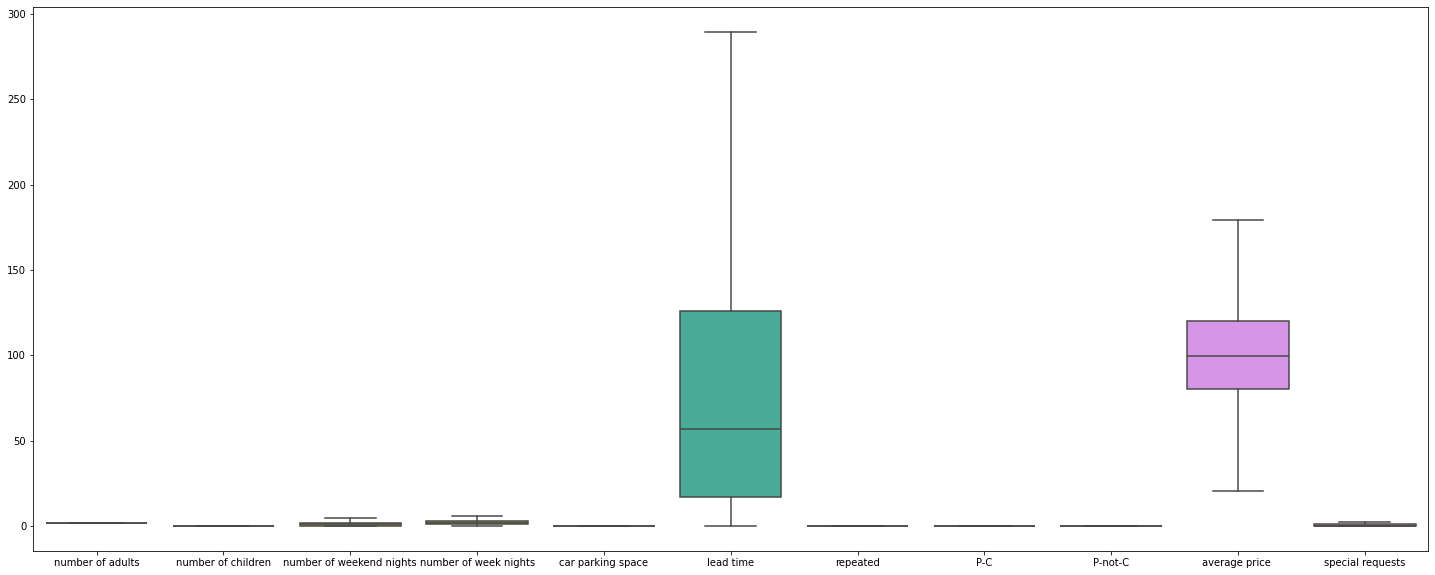

In [26]:
df_capped = df.copy()
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_capped[col] = df[col].clip(lower, upper)
plt.figure(figsize = (25, 10))
sns.boxplot(data=df_capped)
plt.show()


In [27]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in outlier_cols:
    df = remove_outliers(df, col)

In [28]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224.0,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5.0,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1.0,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211.0,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48.0,Online,0,0,0,77.00,0,4/11/2018,Canceled


## **Feature Engineering:**

In [29]:
df['total_nights'] = df['number of weekend nights'] + df['number of week nights']


In [30]:
df['total_guests'] = df['number of adults'] + df['number of children']

In [31]:
df['is_family'] = ((df['number of children'] > 0)).astype(int)

In [32]:
df['is_solo'] = ((df['number of adults'] == 1) & (df['number of children'] == 0)).astype(int)


## **Data Encoding:**

In [33]:
df['booking_status_encoded'] = df['booking status'].map({'Not_Canceled': 0, 'Canceled': 1})

In [34]:
categorical_cols = ['type of meal', 'room type', 'market segment type']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [35]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
0,1,1,2,5,0,224.0,0,0,0,88.00,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,3,0,5.0,0,0,0,106.68,...,0,0,0,0,0,0,0,0,0,1
2,2,1,1,3,0,1.0,0,0,0,50.00,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,2,0,211.0,0,0,0,100.00,...,0,0,0,0,0,0,0,0,0,1
4,1,0,1,2,0,48.0,0,0,0,77.00,...,0,0,0,0,0,0,0,0,0,1


In [36]:
df['booking_status_encoded'] = df['booking status'].map({'Not_Canceled': 0, 'Canceled': 1})

In [37]:
df = df.drop(['booking status', 'date of reservation'], axis=1)

In [38]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
0,1,1,2,5,0,224.0,0,0,0,88.00,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,3,0,5.0,0,0,0,106.68,...,0,0,0,0,0,0,0,0,0,1
2,2,1,1,3,0,1.0,0,0,0,50.00,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,2,0,211.0,0,0,0,100.00,...,0,0,0,0,0,0,0,0,0,1
4,1,0,1,2,0,48.0,0,0,0,77.00,...,0,0,0,0,0,0,0,0,0,1


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36285 entries, 0 to 36284
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   number of adults                   36285 non-null  int64  
 1   number of children                 36285 non-null  int64  
 2   number of weekend nights           36285 non-null  int64  
 3   number of week nights              36285 non-null  int64  
 4   car parking space                  36285 non-null  int64  
 5   lead time                          36285 non-null  float64
 6   repeated                           36285 non-null  int64  
 7   P-C                                36285 non-null  int64  
 8   P-not-C                            36285 non-null  int64  
 9   average price                      36285 non-null  float64
 10  special requests                   36285 non-null  int64  
 11  total_nights                       36285 non-null  int

In [40]:
col_to_scale = df.select_dtypes(include = ['float64', 'int64']).drop(['booking_status_encoded'], axis = 1).columns

scaler = StandardScaler()
df[col_to_scale] = scaler.fit_transform(df[col_to_scale])


In [41]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
0,-1.628431,2.221609,1.366111,1.981250,-0.178794,1.717246,-0.162187,-0.063385,-0.087444,-0.472510,...,0,0,0,0,0,0,0,0,1,0
1,-1.628431,-0.261636,0.217450,0.563741,-0.178794,-0.964571,-0.162187,-0.063385,-0.087444,0.117165,...,0,0,0,0,0,0,0,0,0,1
2,0.299073,2.221609,0.217450,0.563741,-0.178794,-1.013554,-0.162187,-0.063385,-0.087444,-1.672063,...,0,0,0,0,0,0,0,0,0,1
3,-1.628431,-0.261636,-0.931212,-0.145013,-0.178794,1.558051,-0.162187,-0.063385,-0.087444,-0.093704,...,0,0,0,0,0,0,0,0,0,1
4,-1.628431,-0.261636,0.217450,-0.145013,-0.178794,-0.438004,-0.162187,-0.063385,-0.087444,-0.819749,...,0,0,0,0,0,0,0,0,0,1


In [42]:
df.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price ', 'special requests', 'total_nights',
       'total_guests', 'is_family', 'is_solo', 'booking_status_encoded',
       'type of meal_Meal Plan 2', 'type of meal_Meal Plan 3',
       'type of meal_Not Selected', 'room type_Room_Type 2',
       'room type_Room_Type 3', 'room type_Room_Type 4',
       'room type_Room_Type 5', 'room type_Room_Type 6',
       'room type_Room_Type 7', 'market segment type_Complementary',
       'market segment type_Corporate', 'market segment type_Offline',
       'market segment type_Online'],
      dtype='object')

### **Data Balance Checking:**

**In the following figure, the dataset is imbalanced** <br>
**- Note:** 0 : Not_Cancelled , 1: Cancelled

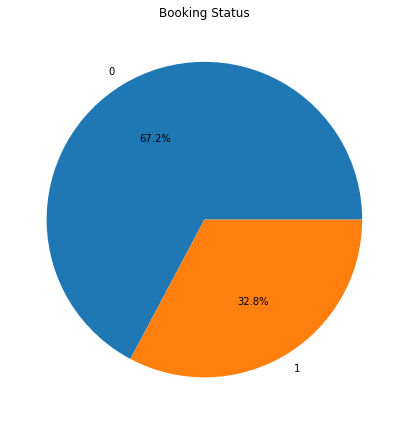

In [43]:
booking_counts = df['booking_status_encoded'].value_counts()

plt.figure(figsize = (6, 6))
plt.pie(booking_counts, labels = booking_counts.index, autopct='%1.1f%%')
plt.title('Booking Status')
plt.tight_layout()
plt.show()


In [44]:
df['booking_status_encoded']

0        0
1        0
2        1
3        1
4        1
        ..
36280    1
36281    0
36282    0
36283    0
36284    0
Name: booking_status_encoded, Length: 36285, dtype: int64

## **Dataset Split (Train and Test):**

In [45]:
X = df.drop(columns=['booking_status_encoded'])
y = df['booking_status_encoded']   

In [46]:
X.head()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,...,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
0,-1.628431,2.221609,1.366111,1.981250,-0.178794,1.717246,-0.162187,-0.063385,-0.087444,-0.472510,...,0,0,0,0,0,0,0,0,1,0
1,-1.628431,-0.261636,0.217450,0.563741,-0.178794,-0.964571,-0.162187,-0.063385,-0.087444,0.117165,...,0,0,0,0,0,0,0,0,0,1
2,0.299073,2.221609,0.217450,0.563741,-0.178794,-1.013554,-0.162187,-0.063385,-0.087444,-1.672063,...,0,0,0,0,0,0,0,0,0,1
3,-1.628431,-0.261636,-0.931212,-0.145013,-0.178794,1.558051,-0.162187,-0.063385,-0.087444,-0.093704,...,0,0,0,0,0,0,0,0,0,1
4,-1.628431,-0.261636,0.217450,-0.145013,-0.178794,-0.438004,-0.162187,-0.063385,-0.087444,-0.819749,...,0,0,0,0,0,0,0,0,0,1


In [47]:
y.head()

0    0
1    0
2    1
3    1
4    1
Name: booking_status_encoded, dtype: int64

In [48]:
print(X.shape)
print(y.shape)
print(type(X), type(y))


(36285, 28)
(36285,)
<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

## **Dealing with Class Imbalanced Problem:**

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

In [54]:
print("Class distribution after oversampling:\n", pd.Series(y_train_res).value_counts())

Class distribution after oversampling:
 0    19517
1    19517
Name: booking_status_encoded, dtype: int64


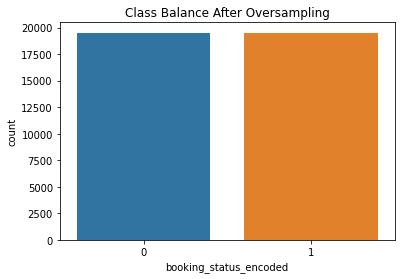

In [ ]:
sns.countplot(x = y_train_res)
plt.title("Class Balance After Oversampling")
plt.show()

## **Data Modeling:**

### 3 Classification Models will be applied: Linear Regression, Polynomaial, Logistic Regression.

### **1) Linear Regression:**

In [117]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_linreg = linreg.predict(X_test)

mse = mean_squared_error(y_test, y_pred_linreg)
r2 = r2_score(y_test, y_pred_linreg)

print("Linear Regression MSE:", mse)
print("Linear Regression R2 Score:", r2)

Linear Regression MSE: 0.14112526865136354
Linear Regression R2 Score: 0.35941559814857016


In [67]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_res, y_train_res)

y_pred_lin = (lin_reg.predict(X_test) > 0.5).astype(int)

print("\n--- Linear Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lin))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lin))
print("Classification Report:\n", classification_report(y_test, y_pred_lin))


--- Linear Regression ---
Accuracy: 0.7886178861788617
Confusion Matrix:
 [[3893  986]
 [ 548 1830]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      4879
           1       0.65      0.77      0.70      2378

    accuracy                           0.79      7257
   macro avg       0.76      0.78      0.77      7257
weighted avg       0.80      0.79      0.79      7257



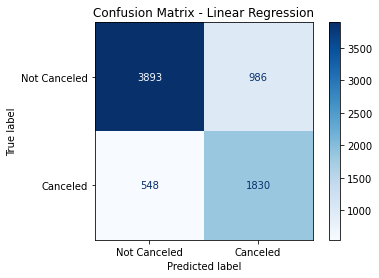

In [78]:
cm = confusion_matrix(y_test, y_pred_lin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Canceled", "Canceled"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Linear Regression")
plt.show()


### **2) Polynomial Regression:**

In [81]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train_res)
X_test_poly = poly.transform(X_test)

In [82]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_train_res)
y_pred_poly = (poly_reg.predict(X_test_poly) > 0.5).astype(int)

In [87]:
mse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression MSE:", mse_poly)
print("Polynomial Regression R2 Score:", r2_poly)

Polynomial Regression MSE: 0.45448782627910966
Polynomial Regression R2 Score: 0.06240326239831506


In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("Classification Report:\n", classification_report(y_test, y_pred_poly))

Accuracy: 0.7934408157640899
Confusion Matrix:
 [[3820 1059]
 [ 440 1938]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.78      0.84      4879
           1       0.65      0.81      0.72      2378

    accuracy                           0.79      7257
   macro avg       0.77      0.80      0.78      7257
weighted avg       0.81      0.79      0.80      7257



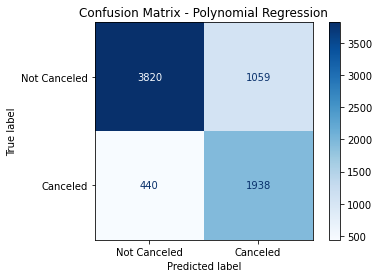

In [90]:
cm = confusion_matrix(y_test, y_pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Not Canceled", "Canceled"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Polynomial Regression")
plt.show()


### **3) Logistic Regression:**

In [91]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_res, y_train_res)

y_pred_log = log_model.predict(X_test)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4879
           1       0.64      0.77      0.70      2378

    accuracy                           0.79      7257
   macro avg       0.76      0.78      0.77      7257
weighted avg       0.80      0.79      0.79      7257

[[3858 1021]
 [ 536 1842]]


c:\Users\sohaa\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


--- Logistic Regression ---
Accuracy: 0.7854485324514262
Confusion Matrix:
 [[3858 1021]
 [ 536 1842]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      4879
           1       0.64      0.77      0.70      2378

    accuracy                           0.79      7257
   macro avg       0.76      0.78      0.77      7257
weighted avg       0.80      0.79      0.79      7257



In [96]:
print("--- Linear Regression ---")
print(classification_report(y_test, y_pred_lin))

print("--- Polynomial Regression ---")
print(classification_report(y_test, y_pred_poly))

print("--- Logistic Regression ---")
print(classification_report(y_test, y_pred_log))


--- Linear Regression ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4879
           1       0.65      0.77      0.70      2378

    accuracy                           0.79      7257
   macro avg       0.76      0.78      0.77      7257
weighted avg       0.80      0.79      0.79      7257

--- Polynomial Regression ---
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      4879
           1       0.65      0.81      0.72      2378

    accuracy                           0.79      7257
   macro avg       0.77      0.80      0.78      7257
weighted avg       0.81      0.79      0.80      7257

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4879
           1       0.64      0.77      0.70      2378

    accuracy                           0.79      7257
   macro avg       0.76      0.78      0.77 

## **Models Comparison:**

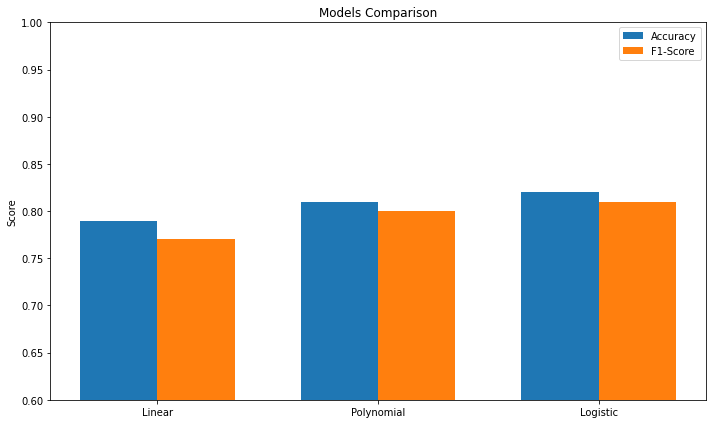

In [98]:
models = ['Linear', 'Polynomial', 'Logistic']
accuracy = [0.79, 0.81, 0.82]
f1_scores = [0.77, 0.80, 0.81]  

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(1, figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_title('Models Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()
